# Day 13 — TensorFlow + Keras + Sequential Neural Networks

Hands-on Colab Notebook


## 1. Import TensorFlow and Libraries


In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 2. Load Iris Dataset

Iris contains 4 numerical features and 3 classes.


In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Features:', iris.feature_names)
print('Classes:', iris.target_names)


X shape: (150, 4)
y shape: (150,)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


## 3. Train/Test Split


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training:', X_train.shape)
print('Testing :', X_test.shape)


Training: (120, 4)
Testing : (30, 4)


## 4. Feature Scaling

Fit the scaler only on training data, then transform both datasets.


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 5. One-Hot Encode Target


In [5]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train, 3)
y_test_encoded = to_categorical(y_test, 3)

print(y_train_encoded[:5])


[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


## 6. Build a Sequential Model

Architecture: Input → Dense(16, ReLU) → Dense(8, ReLU) → Dense(3, Softmax)


In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Compile the Model

Optimizer: Adam | Loss: Categorical Cross-Entropy | Metric: Accuracy


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## 8. Train the Model

`epochs` controls the number of passes and `batch_size` controls samples per update.


In [8]:
history = model.fit(
    X_train, y_train_encoded,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.3542 - loss: 1.1990 - val_accuracy: 0.2500 - val_loss: 1.2150
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.3542 - loss: 1.1409 - val_accuracy: 0.2500 - val_loss: 1.1593
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.3542 - loss: 1.0850 - val_accuracy: 0.2500 - val_loss: 1.1082
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.3542 - loss: 1.0349 - val_accuracy: 0.2500 - val_loss: 1.0617
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.3542 - loss: 0.9895 - val_accuracy: 0.2500 - val_loss: 1.0184
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3646 - loss: 0.9489 - val_accuracy: 0.2500 - val_loss: 0.9789
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4479 - loss: 0.9101 - val_accuracy: 0.4167 - val_loss: 0.9442
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5521 - loss: 0.8753 - val_accuracy: 0.5833 - val_loss: 0.9

## 9. Plot Training and Validation Accuracy


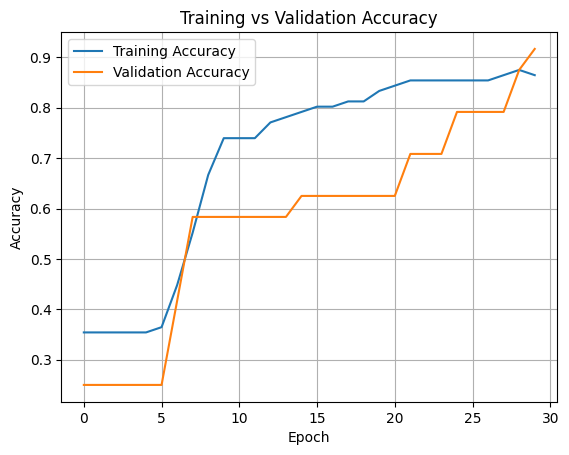

In [9]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()


## 10. Plot Training and Validation Loss


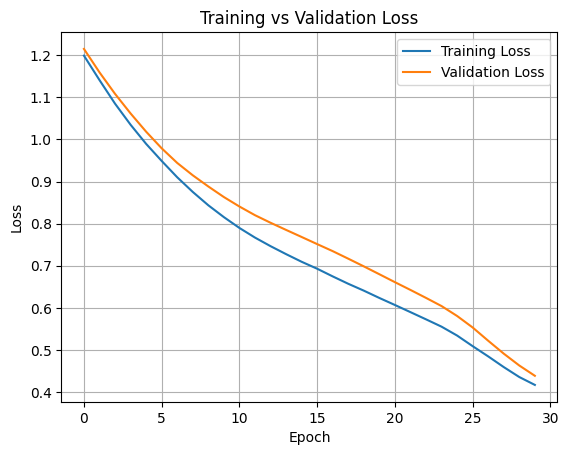

In [10]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()


## 11. Evaluate the Model


In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)


Test Loss: 0.44707149267196655
Test Accuracy: 0.800000011920929


## 12. Make Predictions


In [12]:
probabilities = model.predict(X_test, verbose=0)
predicted_classes = np.argmax(probabilities, axis=1)

print('Predicted:', predicted_classes[:10])
print('Actual   :', y_test[:10])


Predicted: [0 2 1 1 0 2 0 0 2 1]
Actual   : [0 2 1 1 0 1 0 0 2 1]


## 13. Classification Metrics

Use the metrics learned on Day 10.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print('Accuracy :', accuracy_score(y_test, predicted_classes))
print('Precision:', precision_score(y_test, predicted_classes, average='weighted'))
print('Recall   :', recall_score(y_test, predicted_classes, average='weighted'))
print('F1-Score :', f1_score(y_test, predicted_classes, average='weighted'))

print('\nClassification Report:\n')
print(classification_report(y_test, predicted_classes, target_names=iris.target_names))


Accuracy : 0.8
Precision: 0.875
Recall   : 0.8
F1-Score : 0.7802197802197802

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.40      0.57        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.80        30
   macro avg       0.88      0.80      0.78        30
weighted avg       0.88      0.80      0.78        30



## 14. Confusion Matrix


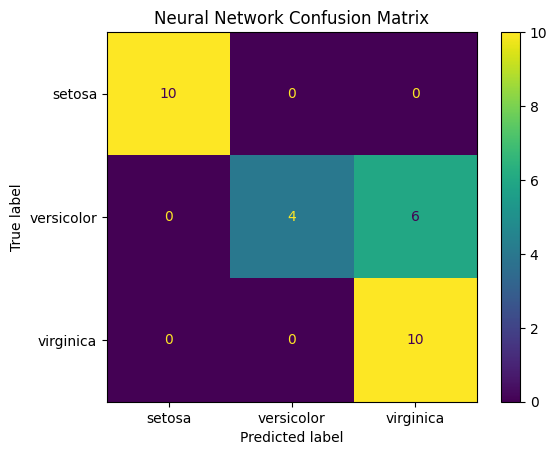

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_classes)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot()
plt.title('Neural Network Confusion Matrix')
plt.show()


## 15. Predict a New Sample

The new sample must use the same preprocessing learned from training data.


In [15]:
new_sample = np.array([[5.9, 3.0, 5.1, 1.8]])
new_sample_scaled = scaler.transform(new_sample)
new_probabilities = model.predict(new_sample_scaled, verbose=0)
new_class = np.argmax(new_probabilities, axis=1)[0]

print('Probabilities:', new_probabilities[0])
print('Predicted class:', iris.target_names[new_class])


Probabilities: [0.06937118 0.247263   0.6833658 ]
Predicted class: virginica


# PART B — DROPOUT

Dropout randomly drops a fraction of neuron outputs during training and can help reduce overfitting.


In [16]:
dropout_model = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(3, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dropout_history = dropout_model.fit(
    X_train, y_train_encoded,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.5000 - loss: 1.0571 - val_accuracy: 0.6250 - val_loss: 0.9963
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4375 - loss: 1.0130 - val_accuracy: 0.6667 - val_loss: 0.9615
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5312 - loss: 0.9642 - val_accuracy: 0.7083 - val_loss: 0.9270
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.9515 - val_accuracy: 0.7083 - val_loss: 0.8964
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6354 - loss: 0.9335 - val_accuracy: 0.7500 - val_loss: 0.8660
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6250 - loss: 0.8614 - val_accuracy: 0.7083 - val_loss: 0.8369
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7188 - loss: 0.8581 - val_accuracy: 0.7500 - val_loss: 0.8082
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6667 - loss: 0.8303 - val_accuracy: 0.7917 - val_loss: 0.7790


# PART C — EARLY STOPPING

Early stopping can stop training when validation loss stops improving.


In [17]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

early_model = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

early_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_history = early_model.fit(
    X_train, y_train_encoded,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

loss, accuracy = early_model.evaluate(X_test, y_test_encoded, verbose=0)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.1875 - loss: 1.5192 - val_accuracy: 0.1667 - val_loss: 1.4931
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2188 - loss: 1.4514 - val_accuracy: 0.1667 - val_loss: 1.4370
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2604 - loss: 1.3965 - val_accuracy: 0.2500 - val_loss: 1.3855
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3021 - loss: 1.3411 - val_accuracy: 0.2917 - val_loss: 1.3444
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3333 - loss: 1.2916 - val_accuracy: 0.2917 - val_loss: 1.3110
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3750 - loss: 1.2501 - val_accuracy: 0.2917 - val_loss: 1.2814
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3958 - loss: 1.2161 - val_accuracy: 0.2500 - val_loss: 1.2558
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4062 - loss: 1.1836 - val_accuracy: 0.2917 - val_loss:

# 🎯 Day 13 Final Flow

`Dataset → Preprocessing → Sequential → Dense Layers → Compile → Fit → Evaluate → Predict`

### Practice
1. Change the number of hidden neurons.
2. Change epochs and batch size.
3. Add/remove a hidden layer.
4. Add Dropout.
5. Use EarlyStopping.
6. Compare validation performance.
